In [ ]:
!pip install tensorflow tqdm

## Imports

In [ ]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Unzip dataset

In [ ]:
!unzip -q "/content/drive/MyDrive/project/combined_dataset.zip" -d "/content/plant_dataset"

In [ ]:
!unzip -q "/content/drive/MyDrive/project/test.zip" -d "/content/plant_dataset"

## parameters

In [ ]:
# Parameters
BATCH_SIZE = 32
IMG_SIZE = (256, 256)
SEED = 42

data_dir = "/content/plant_dataset/combined_dataset"
test_dir = "/content/plant_dataset/test"

## Load Dataset

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Detected {num_classes} species:", class_names)


Found 817 files belonging to 85 classes.
Using 654 files for training.
Found 817 files belonging to 85 classes.
Using 163 files for validation.
Found 170 files belonging to 85 classes.
Detected 85 species: ['Agave_Dasylirioides', 'Agave_Parryi', 'Agave_Striata', 'Ajania_Pacifica', 'Albiflora_Spiraea_Japonica', 'Allium_schoenoprasum_(Chives)', 'Aloe_Bukobana', 'Aloe_Debrana', 'Aloe_Ellenbeckii', 'Aloe_Humilis', 'Alyssum_maritimum', 'Amethyst_Cowichan', 'Apple_Mint_(Mentha_Suaveolens)', 'Arctotis_Midnight_Red', 'Artemisia_afra', 'Ayesha_(Hydrangea_Macrophylla)', 'Baby_Faurax_(Rosa)', 'Bergenia_Ciliata', 'Blue_Chalksticks_(Senecio_Mandraliscae)', 'Brunsvigia_Josephiniae', 'Careus_Monstrosus', 'Chimonanthus_Zhejiangensis', 'Chinese_Fringe', 'Chives_(Allium_Schoenoprasum)', 'Cho-Cho-San_(Camellia_Japonica)', 'Choisya_(White_Dazzler)', 'Coix_Lacrima_jobi', 'Constant_Cheer_(Erysimum)', 'Crispatum_(Farfugium_Japonicum)', 'Daphne_Odora_f_Alba', 'Elegiac_Tectorum_Restiad', 'Erica_Cerinthoides_Re

## Data augementation

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Build EfficientNet Model

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B0

base_model = EfficientNetV2B0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base_model.trainable = False  # freeze base first

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Callbacks

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("efficientnet_plants.keras", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.2)
]

## Train the Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 86s 997ms/step - accuracy: 0.1129 - loss: 4.4592 - val_accuracy: 0.3620 - val_loss: 2.3963 - learning_rate: 0.0100
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.6214 - loss: 1.4758 - val_accuracy: 0.5460 - val_loss: 1.7137 - learning_rate: 0.0100
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.7906 - loss: 0.7318 - val_accuracy: 0.6687 - val_loss: 1.3326 - learning_rate: 0.0100
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.8567 - loss: 0.5520 - val_accuracy: 0.7117 - val_loss: 1.2135 - learning_rate: 0.0100
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.8800 - loss: 0.4247 - val_accuracy: 0.6871 - val_loss: 1.1314 - learning_rate: 0.0100
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.9021 - loss: 0.3455 - val_accuracy: 0.7301 - val_loss: 1.0187 - learning_rate: 0.0100
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9303 - loss: 0.2859 -

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 85)             │       108,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,245,969 (23.83 MB)

 Trainable params: 108,885 (425.33 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 217,772 (850.68 KB)

In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc:.2%}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8168 - loss: 0.8822
Validation Accuracy: 81.60%


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")
print(f" Test Loss: {test_loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 52s 8s/step - accuracy: 0.9430 - loss: 0.2628

 Test Accuracy: 94.12%
 Test Loss: 0.2858


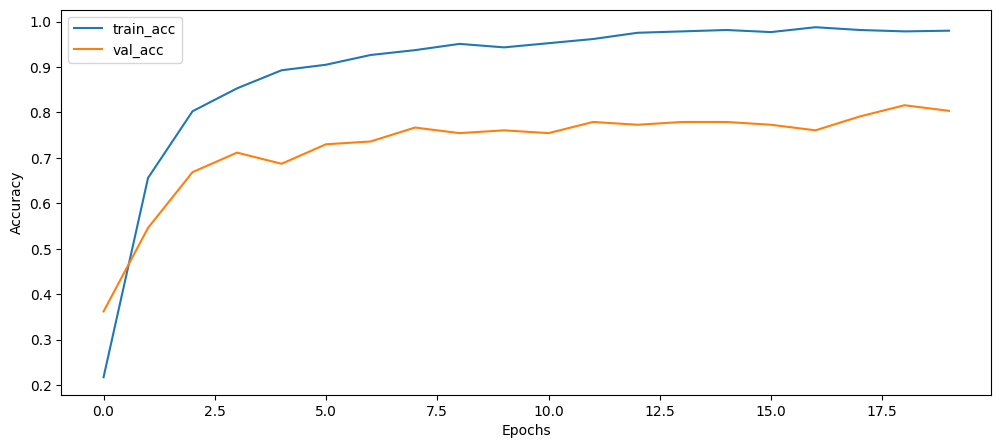

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'] , label='val_acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Fine-Tuning

In [ ]:
base_model.trainable = True
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 59s 596ms/step - accuracy: 0.5875 - loss: 1.6786 - val_accuracy: 0.7791 - val_loss: 0.7871 - learning_rate: 0.0010
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 321ms/step - accuracy: 0.9494 - loss: 0.1906 - val_accuracy: 0.7301 - val_loss: 0.8784 - learning_rate: 0.0010
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 390ms/step - accuracy: 0.9863 - loss: 0.0869 - val_accuracy: 0.8528 - val_loss: 0.5569 - learning_rate: 0.0010
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 324ms/step - accuracy: 0.9942 - loss: 0.0416 - val_accuracy: 0.8466 - val_loss: 0.5969 - learning_rate: 0.0010
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 329ms/step - accuracy: 1.0000 - loss: 0.0216 - val_accuracy: 0.8405 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 389ms/step - accuracy: 0.9976 - loss: 0.0213 - val_accuracy: 0.8466 - val_loss: 0.5309 - learning_rate: 0.0010
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 325ms/step - accuracy: 0.9938 - loss: 0.0243 -

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 85)             │       108,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,963,377 (68.52 MB)

 Trainable params: 5,967,589 (22.76 MB)

 Non-trainable params: 60,608 (236.75 KB)

 Optimizer params: 11,935,180 (45.53 MB)

## Validation data

In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc:.2%}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8569 - loss: 0.5179
Validation Accuracy: 85.28%


##  Test data

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")
print(f" Test Loss: {test_loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9659 - loss: 0.1604

 Test Accuracy: 97.06%
 Test Loss: 0.1405


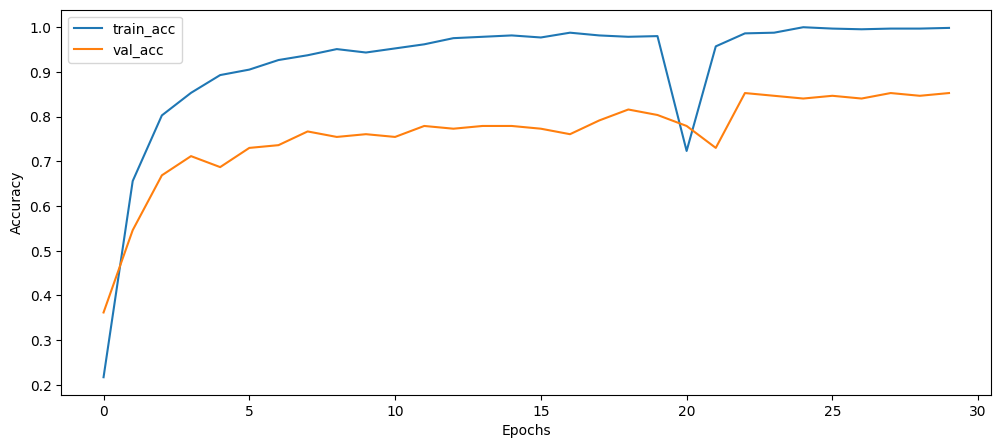

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'] + fine_tune_history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'] + fine_tune_history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9659 - loss: 0.1604


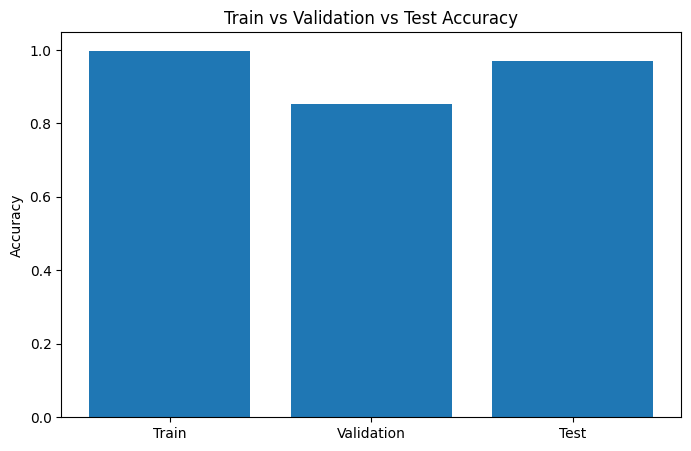

Final Train Accuracy: 0.9985
Final Val Accuracy: 0.8528
Test Accuracy: 0.9706


In [ ]:
train_acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

# Final values
final_train_acc = train_acc[-1]
final_val_acc = val_acc[-1]

# Evaluate test dataset
test_loss, test_acc = model.evaluate(test_ds)

plt.figure(figsize=(8,5))
plt.bar(["Train", "Validation", "Test"],
        [final_train_acc, final_val_acc, test_acc])

plt.ylabel("Accuracy")
plt.title("Train vs Validation vs Test Accuracy")
plt.show()

print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Val Accuracy: {final_val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


In [ ]:
from numpy import test
print(f"Final Training Accuracy: {final_train_acc:.2%}")
print(f"Validation Accuracy: {final_val_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")

Final Training Accuracy: 99.85%
Validation Accuracy: 85.28%
Test Accuracy: 97.06%


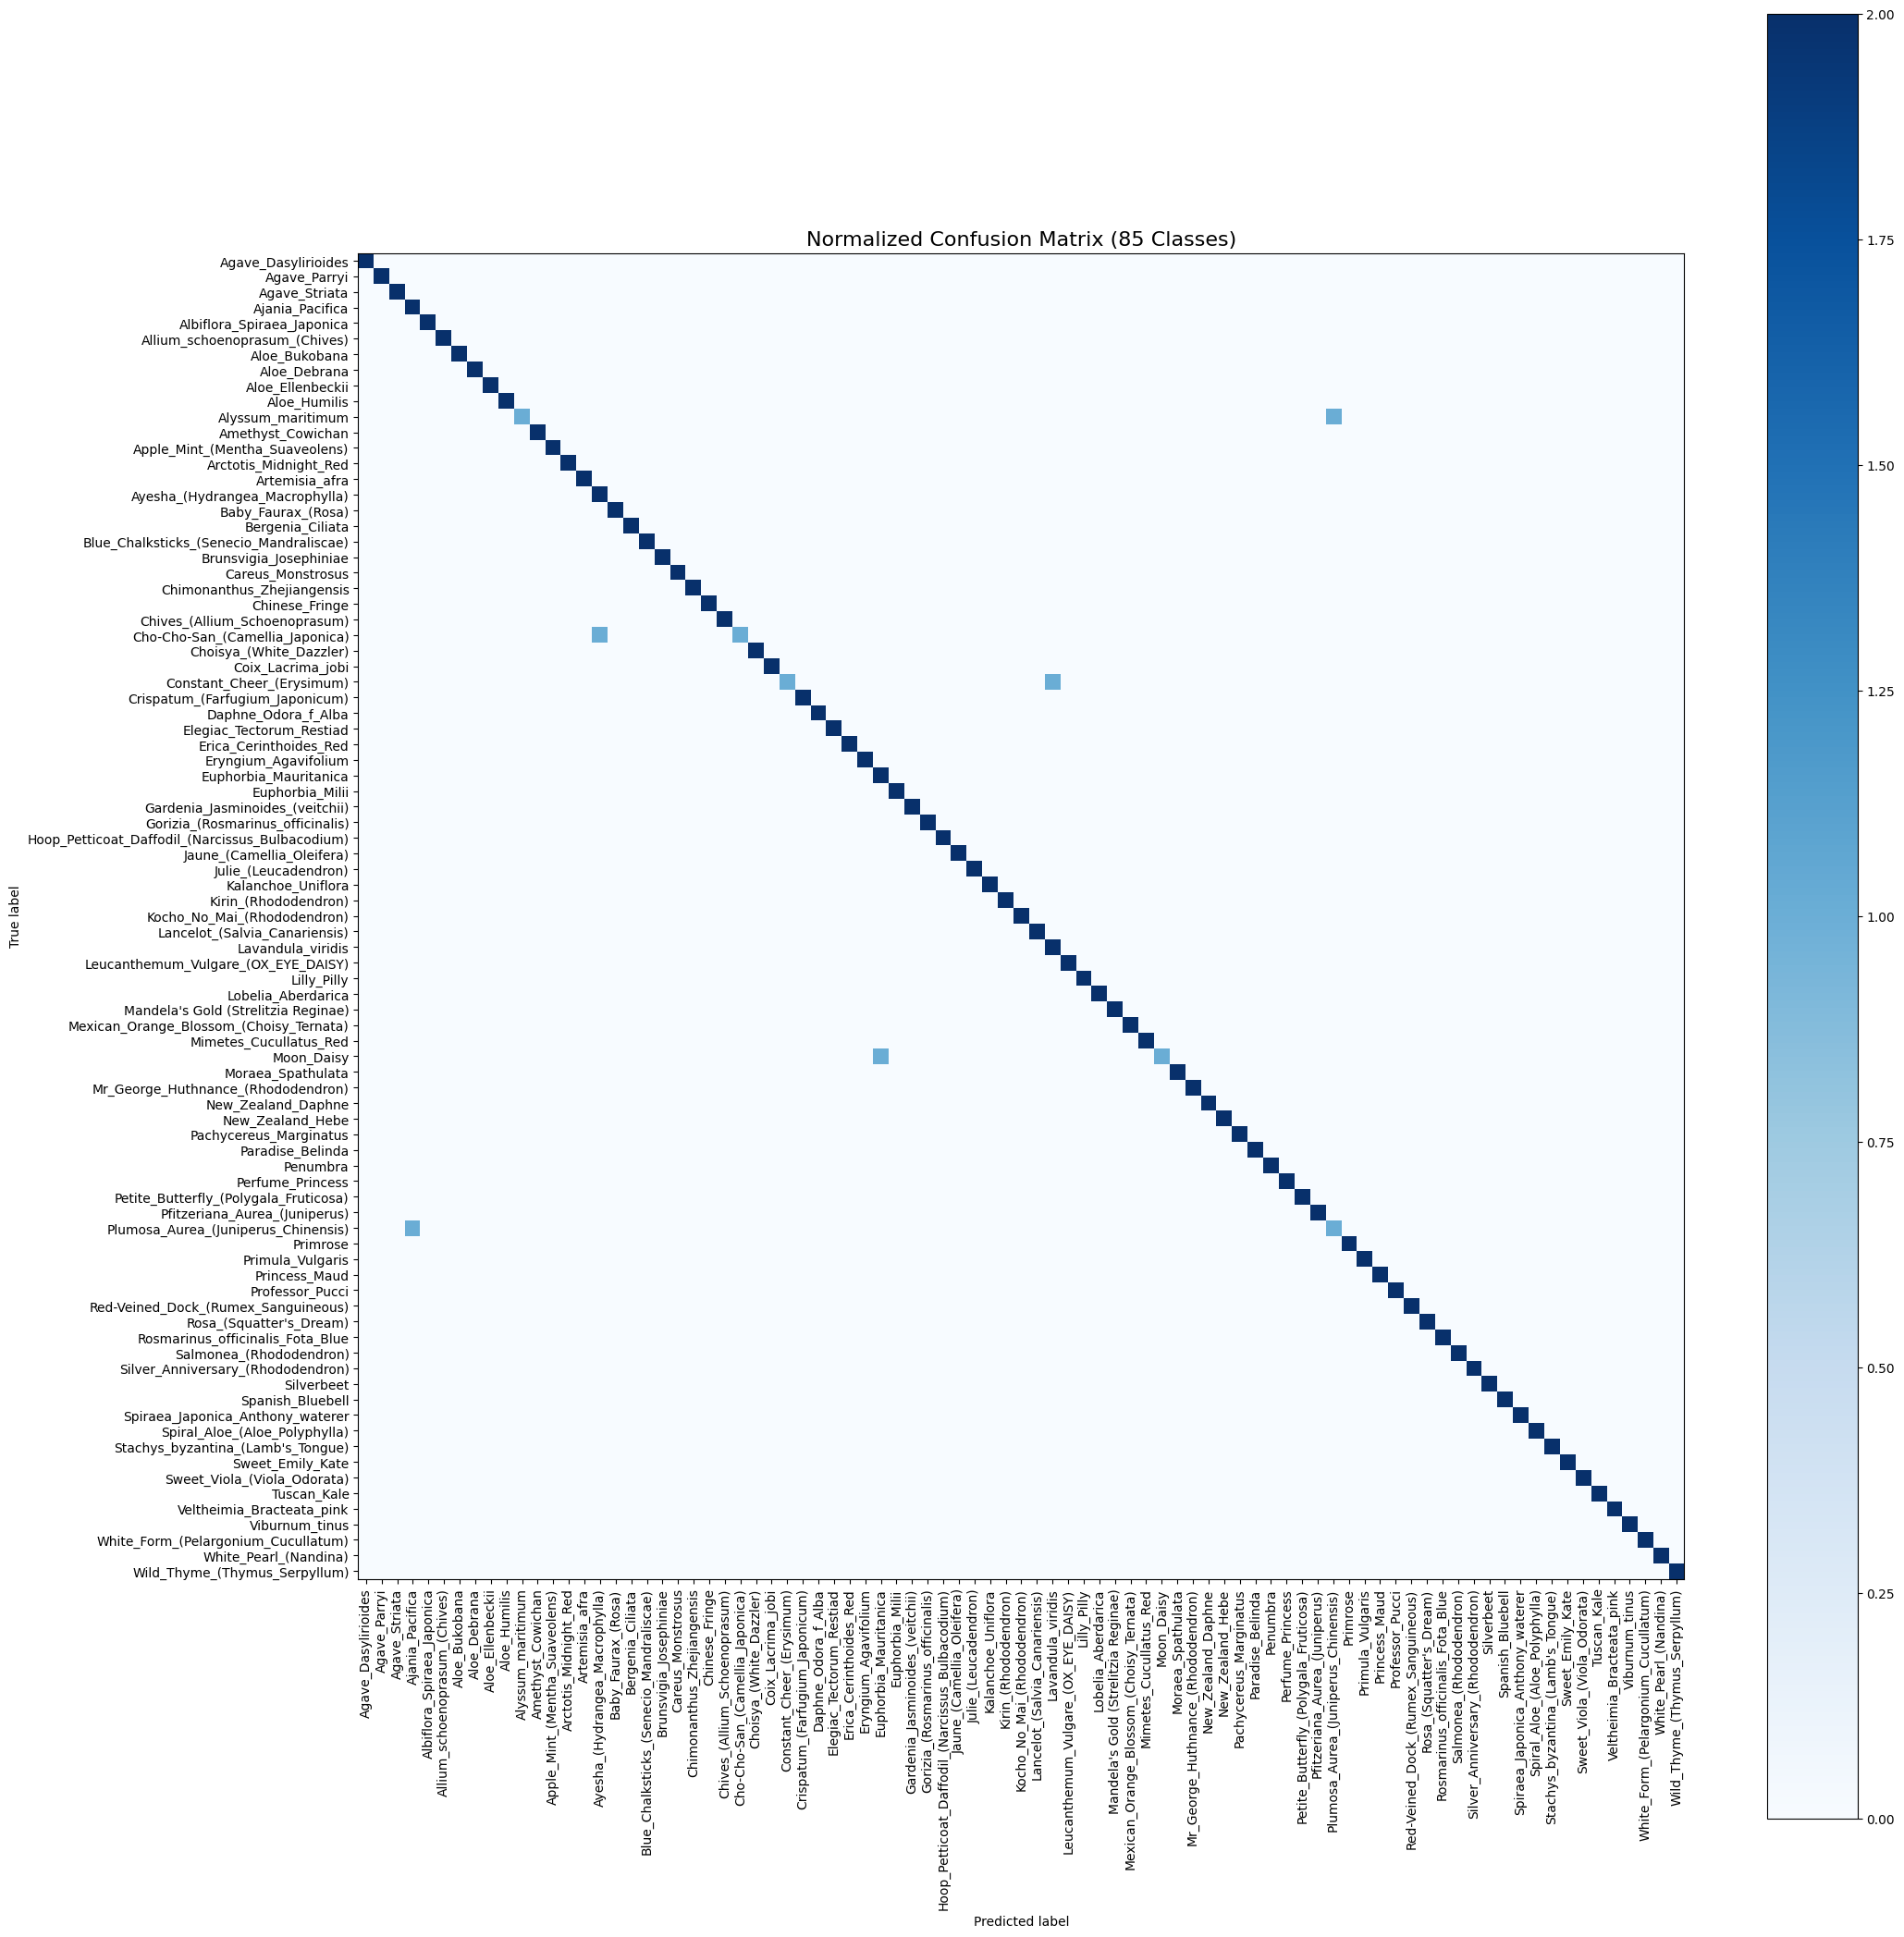

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
# True labels
y_true = np.concatenate([y for _, y in test_ds], axis=0)

# Predictions
y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)

# IMPORTANT FIX: force all labels

labels = np.arange(len(class_names))  # 0 to 84
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(22, 22))
disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
    include_values=False
)

plt.title("Normalized Confusion Matrix (85 Classes)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

labels = np.arange(len(class_names))  # 0 to 84

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))


                                                 precision    recall  f1-score   support

                            Agave_Dasylirioides       1.00      1.00      1.00         2
                                   Agave_Parryi       1.00      1.00      1.00         2
                                  Agave_Striata       1.00      1.00      1.00         2
                                Ajania_Pacifica       0.67      1.00      0.80         2
                     Albiflora_Spiraea_Japonica       1.00      1.00      1.00         2
                  Allium_schoenoprasum_(Chives)       1.00      1.00      1.00         2
                                  Aloe_Bukobana       1.00      1.00      1.00         2
                                   Aloe_Debrana       1.00      1.00      1.00         2
                               Aloe_Ellenbeckii       1.00      1.00      1.00         2
                                   Aloe_Humilis       1.00      1.00      1.00         2
                    

In [ ]:
# Save model and class names
model.save("plant_species_model.keras")
with open("class_names.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")

print("Model and class names saved successfully!")

Model and class names saved successfully!
